In [1]:
import numpy as np
import pandas as pd
import re
from Bio import SeqIO
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, roc_auc_score
from scipy.interpolate import interp1d

# NOTE: Evaluation output filenames were renamed from stacking_* to binned_*; loaders below try binned first and fall back to legacy names.

In [2]:
# ------------------------------------------------------------------
# Paths and data loading (self-standing)
# ------------------------------------------------------------------
base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results'
evaluation_dir = results_dir / 'evaluation_results_fixed05'
figures_dir = base_dir / 'figures'

# Evaluation outputs
method_comparison = pd.read_csv(evaluation_dir / 'method_comparison_stats.csv')
extreme_predictions = pd.read_csv(evaluation_dir / 'extreme_predictions_results.csv')

binned_candidates = [
    evaluation_dir / 'binned_predictions_results.csv',
    evaluation_dir / 'stacking_predictions_results.csv',
]
binned_predictions_path = next((p for p in binned_candidates if p.exists()), None)
if binned_predictions_path is None:
    raise FileNotFoundError(f'No binned/stacking prediction file found in {evaluation_dir}')

histogram_predictions = pd.read_csv(binned_predictions_path)
df_cal = pd.concat([extreme_predictions, histogram_predictions], ignore_index=True)

# Cross-validation hist data
histogram_cv = pd.read_csv(binned_predictions_path)
orf_histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_fixed05/orf_predictions_results.csv')

# Random-sequence prediction data
orf_random_predictions = pd.read_csv(
    '/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/orf_predictions.csv',
    index_col=0
)
contigs_random_predictions = pd.read_csv(
    '/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/contig_predictions.csv',
    index_col=0
)

# Snakemake prediction data
snakemake_orf_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/orf_predictions.csv')
snakemake_contig_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/contig_predictions.csv')

# Ground truth + snakemake contigs (for GT distribution + GT ROC)
gt = pd.read_excel('/home/tobamo/analize/project-tobamo/analysis/data/domain_sci_input/ground_truth_final_added_categories.xlsx')
gt.columns = gt.columns.str.strip()
df_gt = pd.merge(gt, snakemake_contig_predictions, on='contig_name', how='inner').copy()
df_gt['category'] = df_gt['category'].astype(str)
df_gt['prob_1'] = df_gt['prob_1'].astype(float)
if 'predicted_class' not in df_gt.columns:
    df_gt['predicted_class'] = (df_gt['prob_1'] >= 0.5).astype(int)
tobamo_categories = ['tob1', 'tob2', 'tob3']
df_gt['gt_binary'] = df_gt['category'].isin(tobamo_categories).astype(int)

# ------------------------------------------------------------------
# Shared style/config
# ------------------------------------------------------------------
# Edit these in one place for publication-ready typography
FS_TITLE = 12
FS_SUBTITLE = 11
FS_LABEL = 12
FS_TICK = 11
FS_LEGEND = 10
FS_TEXT = 9
padding = 6

plt.style.use('default')
plt.rcParams.update({
    'font.size': FS_LABEL,
    'axes.titlesize': FS_TITLE,
    'axes.labelsize': FS_LABEL,
    'xtick.labelsize': FS_TICK,
    'ytick.labelsize': FS_TICK,
    'legend.fontsize': FS_LEGEND,
    'figure.titlesize': FS_TITLE + 1,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
plt.rcParams['mathtext.fontset'] = 'stix'

colors_ab = ['#0072B2', '#CC79A7']
colors_cd = ['#008B8B', '#50C878']
colors_roc = {'cv': '#D55E00', 'gt': '#009E73'}

category_palette = {
    'tob1': '#006400',
    'tob2': '#32CD32',
    'tob3': '#2E8B57',
    'oth1': '#FFA500',
    'oth2': '#F4A460',
    'oth3': '#CD853F',
    'mas': '#7F7F7F',
}

category_map = {
    'tob1': 'Tobamoviral - known',
    'tob2': 'Tobamoviral - novel',
    'tob3': 'Tobamoviral - difficult',
    'oth1': r'Related to $\it{Virgaviridae}$',
    'oth2': 'Other viruses',
    'mas': 'Misassembled sequences',
}

custom_order = ['tob1', 'tob2', 'tob3', 'oth1', 'oth2', 'oth3', 'mas']

comparison_methods = method_comparison['method'].values
actual_methods = df_cal['mc_name'].unique()

method_mapping = {}
for comp_method in comparison_methods:
    if comp_method == 'extreme':
        if 'most_extreme' in actual_methods:
            method_mapping[comp_method] = 'most_extreme'
        elif 'extreme' in actual_methods:
            method_mapping[comp_method] = 'extreme'
    else:
        method_mapping[comp_method] = comp_method

method_colors = {}
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_colors[comp_method] = colors_ab[i]
    method_colors[actual_method] = colors_ab[i]

# Ground truth category stats for panel D
df_gt_panel = df_gt.copy()
df_gt_panel['correct'] = (df_gt_panel['predicted_class'].astype(int) == df_gt_panel['gt_binary'].astype(int)).astype(int)
cat_stats_df = (
    df_gt_panel
    .groupby('category', as_index=False)
    .agg(total_count=('category', 'size'), correct_count=('correct', 'sum'))
)
cat_stats_df['incorrect_count'] = cat_stats_df['total_count'] - cat_stats_df['correct_count']
cat_stats_df['accuracy'] = cat_stats_df['correct_count'] / cat_stats_df['total_count']
cat_stats_df['order'] = cat_stats_df['category'].map({cat: i for i, cat in enumerate(custom_order)}).fillna(999)
cat_stats_df = cat_stats_df.sort_values(['order', 'total_count']).reset_index(drop=True)

In [3]:
# Ensure required base variables exist
if 'histogram_cv' not in globals():
    eval_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_fixed05')
    cv_candidates = [
        eval_dir / 'binned_predictions_results.csv',
        eval_dir / 'stacking_predictions_results.csv',
    ]
    cv_path = next((p for p in cv_candidates if p.exists()), None)
    if cv_path is None:
        raise FileNotFoundError(f'No binned/stacking CV prediction file found in {eval_dir}')
    histogram_cv = pd.read_csv(cv_path)
if 'figures_dir' not in globals():
    figures_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

# Build evaluation table from CV data
cv = histogram_cv.copy()
cv['ground_truth'] = cv['ground_truth'].astype(int)
cv['prob_1'] = cv['prob_1'].astype(float)
cv['predicted_class'] = (cv['prob_1'] >= 0.5).astype(int)
cv['correct_prediction'] = (cv['predicted_class'] == cv['ground_truth'])

# Keep tobamovirus only
cv_tob = cv[cv['ground_truth'] == 1].copy()

# Parse contig coordinates and accession from contig_name
cv_tob['contig_start'] = cv_tob['contig_name'].str.extract(r'_start-(\d+)').astype(float)
cv_tob['contig_length'] = cv_tob['contig_name'].str.extract(r'_len-(\d+)').astype(float)
cv_tob['contig_end'] = cv_tob['contig_start'] + cv_tob['contig_length']
cv_tob['accession'] = cv_tob['contig_name'].str.extract(r'^([^_]+)')

# Reference length mapping from FASTA (same approach as results_overview)
reference_fasta = '/home/tobamo/analize/project-tobamo/analysis/data/tobamo/reference_nukleotidne.fasta'
refs_lens = {}
for rec in SeqIO.parse(reference_fasta, 'fasta'):
    m = re.match(r'^(.*\.\d+)_', rec.id)
    if m:
        refs_lens[m.group(1)] = len(rec.seq)
    else:
        refs_lens[rec.id.split('_')[0]] = len(rec.seq)

cv_tob['ref_len'] = cv_tob['accession'].map(refs_lens).astype(float)

# Drop rows with unresolved coordinates/lengths
before_rows = len(cv_tob)
cv_tob = cv_tob.dropna(subset=['contig_start', 'contig_end', 'ref_len']).copy()
cv_tob = cv_tob[cv_tob['ref_len'] > 0]

# Relative coordinates
cv_tob['relative_start'] = cv_tob['contig_start'] / cv_tob['ref_len']
cv_tob['relative_end'] = cv_tob['contig_end'] / cv_tob['ref_len']
cv_tob['relative_start'] = cv_tob['relative_start'].clip(0, 1)
cv_tob['relative_end'] = cv_tob['relative_end'].clip(0, 1)

# Coverage bins
bins = 1000
coverage_correct = np.zeros(bins)
coverage_false = np.zeros(bins)

for is_correct, grp in cv_tob.groupby('correct_prediction'):
    for start, end in zip(grp['relative_start'].values, grp['relative_end'].values):
        start_bin = max(0, min(bins - 1, int(start * bins)))
        end_bin = max(start_bin + 1, min(bins, int(np.ceil(end * bins))))
        if is_correct:
            coverage_correct[start_bin:end_bin] += 1
        else:
            coverage_false[start_bin:end_bin] += 1

# Error rate (false / total)
total_coverage = coverage_correct + coverage_false
error_rate = np.divide(coverage_false, total_coverage, out=np.zeros_like(coverage_false), where=total_coverage != 0)

coverage_df = pd.DataFrame({
    'Relative Position': np.linspace(0, 1, bins),
    'Coverage_True': coverage_correct,
    'Coverage_False': coverage_false,
    'Error Rate': error_rate,
})
coverage_df['Smoothed Error Rate'] = coverage_df['Error Rate'].rolling(window=20, center=True).mean().fillna(0)


# ORF/ROI regions (same as results_overview)
rdrp_orf1_start = 77 / 6393
rdrp_orf1_end = 3348 / 6393
rdrp_orf2_start = 3350 / 6393
rdrp_orf2_end = 4924 / 6393
mp_start = 4911 / 6393
mp_end = 5711 / 6393
cp_start = 5714 / 6393
cp_end = 6193 / 6393

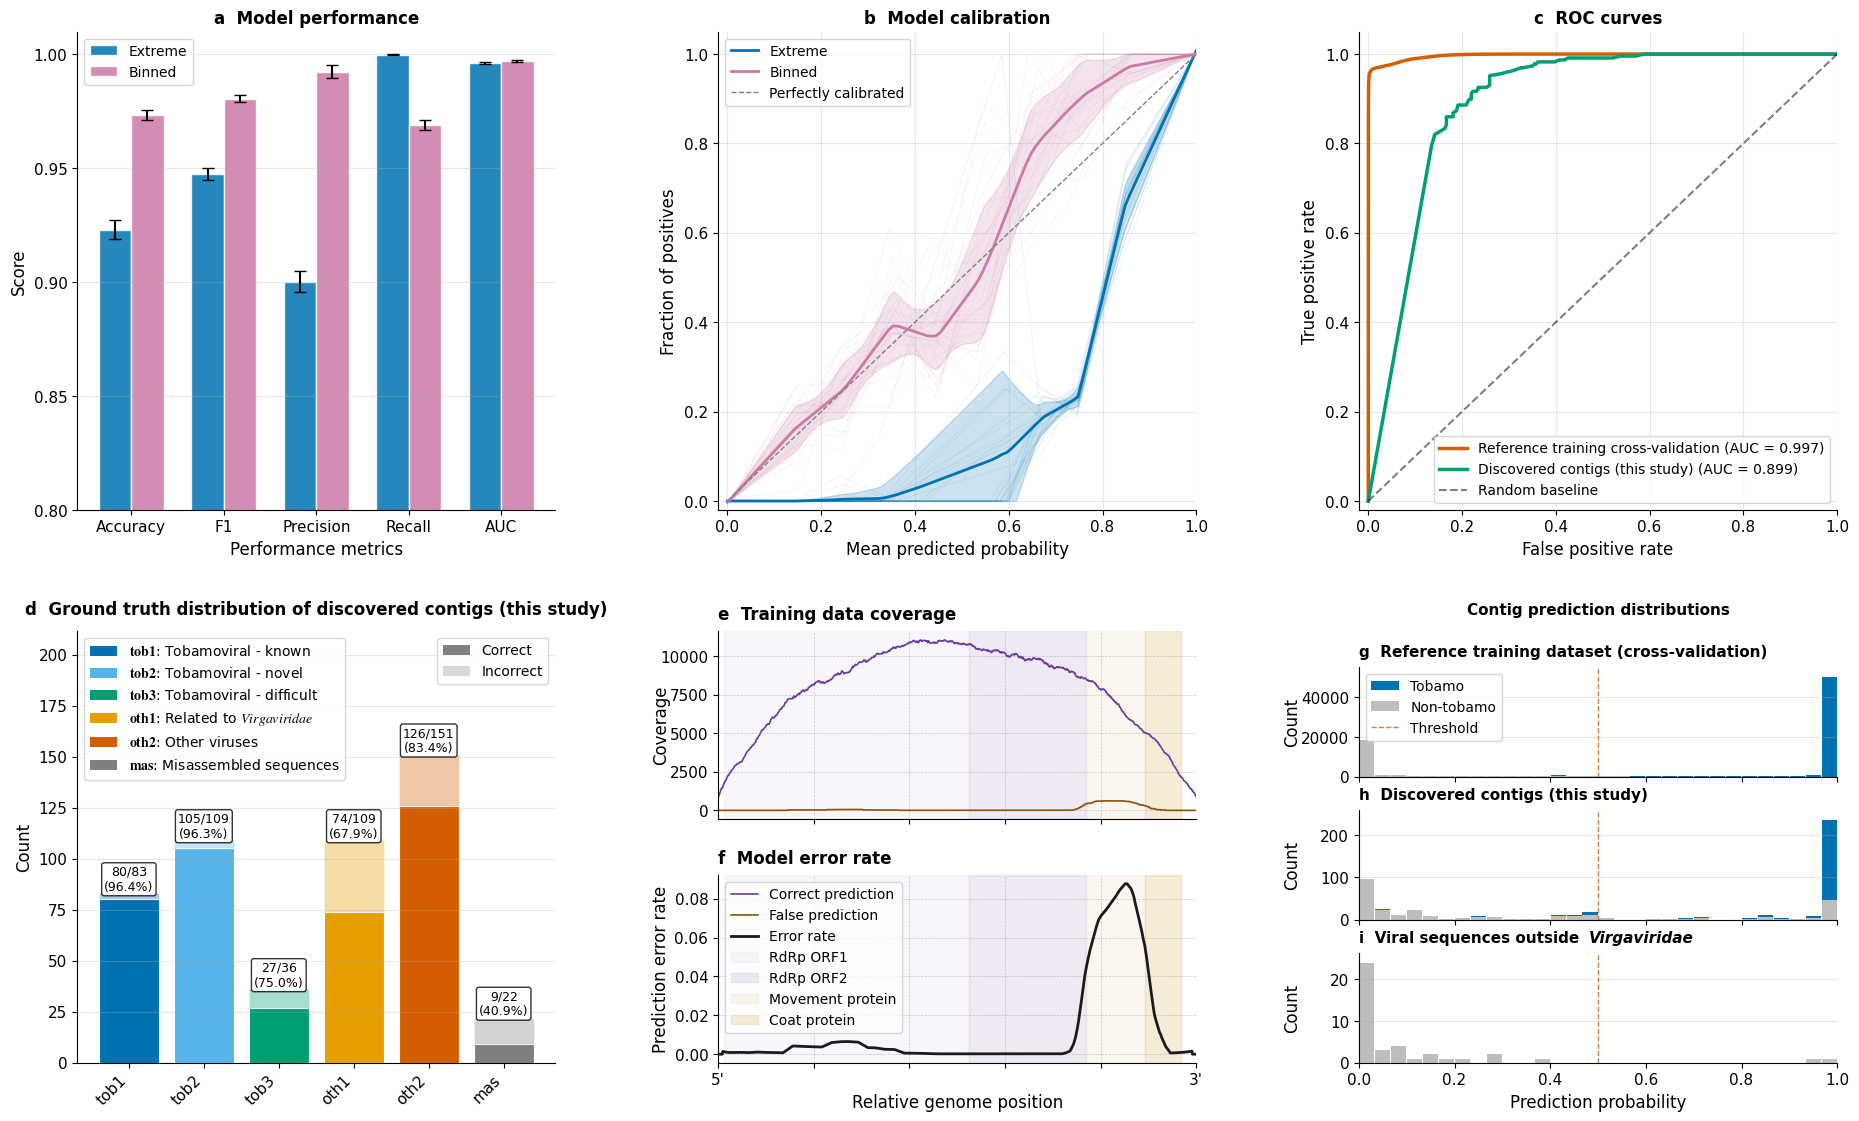

In [4]:
# New panel at end: 3x2 layout with stacked F

fig = plt.figure(figsize=(20, 12.5))
gs_outer = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.7], hspace=0.1, wspace=0.34)
PANEL_TITLE_Y = 1.02
padding = 6

# ---------------- Row 1: A, B, C (same) ----------------
# A. Model performance
ax_a = fig.add_subplot(gs_outer[0, 0])
metrics = ['accuracy', 'f1', 'precision', 'recall', 'auc']
metric_labels = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
x = np.arange(len(metrics))
width = 0.35
bar_positions = [x - width / 2, x + width / 2]

for i, comp_method in enumerate(comparison_methods):
    means = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_mean'].iloc[0] for metric in metrics]
    stds = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_std'].iloc[0] for metric in metrics]
    display_method = 'Binned' if str(comp_method).strip().lower() in {'histogram', 'stacking', 'binned'} else comp_method
    ax_a.bar(
        bar_positions[i], means, width, yerr=stds, capsize=4,
        label=display_method.capitalize(), alpha=0.85,
        color=method_colors[comp_method], edgecolor='white', linewidth=1.0
    )

ax_a.set_xticks(x)
ax_a.set_xticklabels(metric_labels)
ax_a.set_xlabel('Performance metrics')
ax_a.set_ylabel('Score')
ax_a.set_ylim(0.80, 1.01)
ax_a.set_yticks([0.80, 0.85, 0.90, 0.95, 1.00])
ax_a.grid(axis='y', alpha=0.3)
ax_a.set_title('a  Model performance', fontweight='bold')
ax_a.legend(loc='upper left', frameon=True)
ax_a.set_box_aspect(1)

# B. Model calibration
ax_b = fig.add_subplot(gs_outer[0, 1])
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_data = df_cal[df_cal['mc_name'] == actual_method]
    if len(method_data) == 0:
        continue

    prob_true_values = []
    prob_pred_values = []
    iterations = method_data['iteration'].unique() if 'iteration' in method_data.columns else [0]

    for iteration in iterations:
        iter_data = method_data[method_data['iteration'] == iteration] if 'iteration' in method_data.columns else method_data
        if len(iter_data) == 0:
            continue

        y_true = iter_data['ground_truth']
        y_scores = iter_data['prob_1']
        if len(y_true) > 10 and len(np.unique(y_true)) > 1:
            prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10)
            ax_b.plot(prob_pred, prob_true, color=method_colors[comp_method], alpha=0.1, lw=0.5)
            prob_true_values.append(prob_true)
            prob_pred_values.append(prob_pred)

    if prob_true_values:
        x_interp = np.linspace(0, 1, 100)
        interp_curves = []
        for prob_true, prob_pred in zip(prob_true_values, prob_pred_values):
            if len(prob_pred) > 1:
                interp_func = interp1d(prob_pred, prob_true, bounds_error=False, fill_value='extrapolate')
                interp_curves.append(interp_func(x_interp))

        if interp_curves:
            interp_array = np.array(interp_curves)
            mean_curve = np.nanmean(interp_array, axis=0)
            std_curve = np.nanstd(interp_array, axis=0)
            display_method = 'Binned' if str(comp_method).strip().lower() in {'histogram', 'stacking', 'binned'} else comp_method
            ax_b.plot(x_interp, mean_curve, color=method_colors[comp_method], lw=2, label=display_method.capitalize())
            ax_b.fill_between(
                x_interp,
                np.maximum(0, mean_curve - std_curve),
                np.minimum(1, mean_curve + std_curve),
                color=method_colors[comp_method],
                alpha=0.2,
            )

ax_b.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Perfectly calibrated')
ax_b.set_xlim(-0.02, 1.0)
ax_b.set_ylim(-0.02, 1.05)
ax_b.set_yticks(np.linspace(0, 1.0, 6))
ax_b.set_xlabel('Mean predicted probability')
ax_b.set_ylabel('Fraction of positives')
ax_b.grid(True, alpha=0.3)
ax_b.set_title('b  Model calibration', fontweight='bold')
ax_b.legend(loc='upper left', frameon=True)
ax_b.set_box_aspect(1)

# C. ROC curves
ax_c = fig.add_subplot(gs_outer[0, 2])
y_true_cv = histogram_cv['ground_truth'].astype(int)
y_scores_cv = histogram_cv['prob_1'].astype(float)
auc_cv = roc_auc_score(y_true_cv, y_scores_cv)
thresholds = np.linspace(0, 1, 101)
fpr_cv, tpr_cv = [], []
for threshold in thresholds:
    pred_thresh = (y_scores_cv >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_cv, pred_thresh).ravel()
    fpr_cv.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_cv.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

y_true_gt = df_gt['gt_binary'].astype(int)
y_scores_gt = df_gt['prob_1'].astype(float)
auc_gt = roc_auc_score(y_true_gt, y_scores_gt)
fpr_gt, tpr_gt = [], []
for threshold in thresholds:
    pred_thresh = (y_scores_gt >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_gt, pred_thresh).ravel()
    fpr_gt.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_gt.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

ax_c.plot(fpr_cv, tpr_cv, linewidth=2.5, color=colors_roc['cv'], label=f'Reference training cross-validation (AUC = {auc_cv:.3f})')
ax_c.plot(fpr_gt, tpr_gt, linewidth=2.5, color=colors_roc['gt'], label=f'Discovered contigs (this study) (AUC = {auc_gt:.3f})')
ax_c.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random baseline')
ax_c.set_xlim(-0.02, 1.0)
ax_c.set_ylim(-0.02, 1.05)
ax_c.set_yticks(np.linspace(0, 1.0, 6))
ax_c.set_xlabel('False positive rate')
ax_c.set_ylabel('True positive rate')
ax_c.grid(True, alpha=0.3)
ax_c.set_title('c  ROC curves', fontweight='bold')
ax_c.legend(loc='lower right', frameon=True)
ax_c.set_box_aspect(1)

# Shrink first-row panels (A, B, C) to 90% while keeping centers fixed
for ax_ in (ax_a, ax_b, ax_c):
    pos = ax_.get_position()
    scale = 0.90
    new_w = pos.width * scale
    new_h = pos.height * scale
    ax_.set_position([
        pos.x0 + (pos.width - new_w) / 2,
        pos.y0 + (pos.height - new_h) / 2,
        new_w,
        new_h,
    ])

# ---------------- Row 2: D, E, F ----------------
# D. Ground truth distribution
ax_d = fig.add_subplot(gs_outer[1, 0])
cat_stats_d = cat_stats_df.copy()
custom_order = ['tob1', 'tob2', 'tob3', 'oth1', 'oth2', 'oth3', 'mas']
panel_d_order = [cat for cat in custom_order if cat in cat_stats_d['category'].values]
cat_stats_d['category'] = pd.Categorical(cat_stats_d['category'], categories=panel_d_order, ordered=True)
cat_stats_d = cat_stats_d.sort_values('category')

# Colorblind-safe category palette for panel D
category_palette_d = {
    'tob1': '#0072B2',
    'tob2': '#56B4E9',
    'tob3': '#009E73',
    'oth1': '#E69F00',
    'oth2': '#D55E00',
    'oth3': '#CC79A7',
    'mas': '#7F7F7F',
}

x_positions = np.arange(len(cat_stats_d))
bar_colors = [category_palette_d.get(cat, '#999999') for cat in cat_stats_d['category']]

ax_d.bar(x_positions, cat_stats_d['correct_count'], color=bar_colors, alpha=1.0, edgecolor='white', linewidth=0.8)
ax_d.bar(
    x_positions,
    cat_stats_d['incorrect_count'],
    bottom=cat_stats_d['correct_count'],
    color=bar_colors,
    alpha=0.35,
    edgecolor='white',
    linewidth=0.8
)

ax_d.set_xticks(x_positions)
ax_d.set_xticklabels(cat_stats_d['category'], rotation=45, ha='right')
ax_d.set_ylabel('Count')
ax_d.set_title('d  Ground truth distribution of discovered contigs (this study)', fontweight='bold', y=PANEL_TITLE_Y, pad=padding)

# make D a bit less wide and shift left
pos_d = ax_d.get_position()
new_w_d = pos_d.width * 0.90
shift_d_left = pos_d.width * 0.03
ax_d.set_position([
    pos_d.x0 - shift_d_left + (pos_d.width - new_w_d) / 2,
    pos_d.y0,
    new_w_d,
    pos_d.height,
])

for i, row in cat_stats_d.iterrows():
    total = int(row['total_count'])
    correct = int(row['correct_count'])
    acc = row['accuracy'] * 100
    ax_d.text(
        i,
        total + max(1, cat_stats_d['total_count'].max() * 0.01),
        f'{correct}/{total}\n({acc:.1f}%)',
        ha='center',
        fontsize=FS_TEXT,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8)
    )

if len(cat_stats_d) > 0:
    ax_d.set_ylim(0, cat_stats_d['total_count'].max() * 1.4)
ax_d.grid(True, axis='y', alpha=0.3)

legend_handles = []
for cat in panel_d_order:
    if cat in cat_stats_d['category'].values:
        patch = plt.Rectangle((0, 0), 1, 1, fc=category_palette_d.get(cat, '#999999'))
        legend_handles.append((patch, rf"$\bf{{{cat}}}$: {category_map.get(cat, cat)}"))
if legend_handles:
    patches, labels = zip(*legend_handles)
    category_legend = ax_d.legend(
        patches,
        labels,
        loc='upper left',
        fontsize=FS_LEGEND,
        ncol=1,
        frameon=True,
    )
    ax_d.add_artist(category_legend)

legend_elements_accuracy = [
    plt.Rectangle((0, 0), 1, 1, facecolor='gray', alpha=1.0, label='Correct'),
    plt.Rectangle((0, 0), 1, 1, facecolor='gray', alpha=0.3, label='Incorrect')
]
ax_d.legend(
    handles=legend_elements_accuracy,
    loc='upper right',
    # bbox_to_anchor=(0.0, 0.75),
    fontsize=FS_LEGEND,
    frameon=True,
)

# E. Coverage + error rate as two subplots
# Error rate (false / total)
total_coverage = coverage_correct + coverage_false
error_rate = np.divide(coverage_false, total_coverage, out=np.zeros_like(coverage_false), where=total_coverage != 0)

coverage_df = pd.DataFrame({
    'Relative Position': np.linspace(0, 1, bins),
    'Coverage_True': coverage_correct,
    'Coverage_False': coverage_false,
    'Error Rate': error_rate,
})
coverage_df['Smoothed Error Rate'] = coverage_df['Error Rate'].rolling(window=20, center=True).mean().fillna(0)

# Colorblind-friendly E palette; intentionally distinct from A/B and D
panel_e_colors = {
    'coverage_true': '#6A3D9A',
    'coverage_false': '#8C510A',
    'error_rate': '#1B1B1B',
    'rdrp_orf1': '#E8E1F2',
    'rdrp_orf2': '#CDB7DD',
    'movement_protein': '#F2E2CC',
    'coat_protein': '#DFC27D',
}

ax_e_parent = fig.add_subplot(gs_outer[1, 1])
gs_e = ax_e_parent.get_subplotspec().subgridspec(2, 1, hspace=0.30)
ax_e1 = fig.add_subplot(gs_e[0])
ax_e2 = fig.add_subplot(gs_e[1])
ax_e_parent.set_frame_on(False)
ax_e_parent.set_xticks([])
ax_e_parent.set_yticks([])
# ax_e_parent.set_title('Training data coverage and model error rate', fontweight='bold', y=PANEL_TITLE_Y, pad=padding)

# move E slightly to the left
pos_e_parent = ax_e_parent.get_position()
shift_e_left = pos_e_parent.width * 0.03
ax_e_parent.set_position([
    pos_e_parent.x0 - shift_e_left,
    pos_e_parent.y0,
    pos_e_parent.width,
    pos_e_parent.height,
])
for ax_ in (ax_e1, ax_e2):
    pos_e = ax_.get_position()
    ax_.set_position([
        pos_e.x0 - shift_e_left,
        pos_e.y0,
        pos_e.width,
        pos_e.height,
    ])

if 'coverage_df' not in globals():
    raise RuntimeError('Please run the bottom coverage/error preparation cell first (Cell 5).')

# E1 coverage
ax_e1.plot(
    coverage_df['Relative Position'],
    coverage_df['Coverage_True'],
    color=panel_e_colors['coverage_true'],
    label='Correct prediction',
    linewidth=1.2,
)
ax_e1.plot(
    coverage_df['Relative Position'],
    coverage_df['Coverage_False'],
    color=panel_e_colors['coverage_false'],
    label='False prediction',
    linewidth=1.2,
)
ax_e1.set_title('e  Training data coverage', fontweight='bold', loc='left', y=PANEL_TITLE_Y, pad=padding)
ax_e1.set_ylabel('Coverage', fontsize=FS_LABEL)
ax_e1.grid(visible=True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
ax_e1.set_xlim(0, 1)
ax_e1.set_xticks([0.2, 0.4, 0.6, 0.8])
ax_e1.set_xticklabels([])

# E2 error rate
ax_e2.plot(
    coverage_df['Relative Position'],
    coverage_df['Smoothed Error Rate'],
    color=panel_e_colors['error_rate'],
    label='Error rate',
    linewidth=2,
)
ax_e2.set_title('f  Model error rate', fontweight='bold', loc='left', y=PANEL_TITLE_Y, pad=padding)
ax_e2.set_xlabel('Relative genome position', fontsize=FS_LABEL)
ax_e2.set_ylabel('Prediction error rate', fontsize=FS_LABEL)
ax_e2.grid(visible=True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
ax_e2.set_xlim(0, 1)
ax_e2.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax_e2.set_xticklabels(["5'", "", "", "", "", "3'"])
for ax_ in (ax_e1, ax_e2):
    ax_.yaxis.set_label_coords(-0.10, 0.5)

# ORF/ROI spans on both E subplots
for ax_ in (ax_e1, ax_e2):
    ax_.axvspan(rdrp_orf1_start, rdrp_orf1_end, color=panel_e_colors['rdrp_orf1'], alpha=0.30, label='RdRp ORF1')
    ax_.axvspan(rdrp_orf2_start, rdrp_orf2_end, color=panel_e_colors['rdrp_orf2'], alpha=0.30, label='RdRp ORF2')
    ax_.axvspan(mp_start, mp_end, color=panel_e_colors['movement_protein'], alpha=0.30, label='Movement protein')
    ax_.axvspan(cp_start, cp_end, color=panel_e_colors['coat_protein'], alpha=0.30, label='Coat protein')

# Combined E legend inside lower plot
handles_e1, labels_e1 = ax_e1.get_legend_handles_labels()
handles_e2, labels_e2 = ax_e2.get_legend_handles_labels()
handles_e, labels_e = [], []
for h, l in zip(handles_e1 + handles_e2, labels_e1 + labels_e2):
    if l not in labels_e:
        handles_e.append(h)
        labels_e.append(l)
desired_order_e = ['Correct prediction', 'False prediction', 'Error rate', 'RdRp ORF1', 'RdRp ORF2', 'Movement protein', 'Coat protein']
ordered_e = [(h, l) for h, l in zip(handles_e, labels_e) if l in desired_order_e]
ordered_e.sort(key=lambda x: desired_order_e.index(x[1]))
if ordered_e:
    oe_h, oe_l = zip(*ordered_e)
    ax_e2.legend(oe_h, oe_l, loc='upper left', fontsize=FS_LEGEND, frameon=True)

# ---------------- F panel: contigs colored by ground truth ----------------
truth_colors_f = {1: '#0072B2', 0: '#7F7F7F'}
truth_labels_f = {1: 'Tobamo', 0: 'Non-tobamo'}

def plot_compact_contig_panel(ax, contig_eval_df, truth_col, title):
    eval_df = contig_eval_df.copy()
    eval_df['prob_1'] = pd.to_numeric(eval_df['prob_1'], errors='coerce')
    eval_df[truth_col] = pd.to_numeric(eval_df[truth_col], errors='coerce').fillna(0).astype(int)
    eval_df = eval_df.dropna(subset=['prob_1'])

    bins_local = np.linspace(0, 1, 31)
    tob_vals = eval_df.loc[eval_df[truth_col] == 1, 'prob_1'].astype(float)
    non_vals = eval_df.loc[eval_df[truth_col] == 0, 'prob_1'].astype(float)

    tob_hist, _ = np.histogram(tob_vals, bins=bins_local)
    non_hist, _ = np.histogram(non_vals, bins=bins_local)
    bin_centers = (bins_local[:-1] + bins_local[1:]) / 2
    bin_width = (bins_local[1] - bins_local[0]) * 0.95

    ax.bar(bin_centers, non_hist, width=bin_width, color=truth_colors_f[0], alpha=0.5, label=truth_labels_f[0])
    ax.bar(bin_centers, tob_hist, width=bin_width, bottom=non_hist, color=truth_colors_f[1], label=truth_labels_f[1])

    max_height = max(1, np.max(non_hist + tob_hist))
    ax.set_ylim(0, max_height * 1.1)
    ax.set_xlim(0, 1)
    title_obj = ax.set_title(title, fontsize=FS_SUBTITLE, loc='left', y=PANEL_TITLE_Y, pad=padding, fontweight='bold')
    ax.set_xlabel('Prediction probability', fontsize=FS_LABEL)
    ax.set_ylabel('Count', fontsize=FS_LABEL)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='both', labelsize=FS_TICK)
    ax.axvline(x=0.5, color='#D55E00', linestyle='--', linewidth=1.0, alpha=0.8, label='Threshold')
    return title_obj

ax_f_parent = fig.add_subplot(gs_outer[1, 2])
ax_f_parent.set_frame_on(False)
ax_f_parent.set_xticks([])
ax_f_parent.set_yticks([])
ax_f_parent.set_title('Contig prediction distributions', fontweight='bold', y=PANEL_TITLE_Y)#, pad=padding)

gs_f = ax_f_parent.get_subplotspec().subgridspec(4, 1, height_ratios=[0.02, 1, 1, 1], hspace=0.4)
ax_f1 = fig.add_subplot(gs_f[1])
ax_f2 = fig.add_subplot(gs_f[2], sharex=ax_f1)
ax_f3 = fig.add_subplot(gs_f[3], sharex=ax_f1)

plot_compact_contig_panel(
    ax_f1,
    histogram_cv.copy(),
    'ground_truth',
    'g  Reference training dataset (cross-validation)'
)
plot_compact_contig_panel(ax_f2, df_gt.copy(), 'gt_binary', 'h  Discovered contigs (this study)')

random_non_tob = contigs_random_predictions.copy()
random_non_tob['gt_binary'] = 0
title_i_prefix = plot_compact_contig_panel(
    ax_f3,
    random_non_tob,
    'gt_binary',
    'i  Viral sequences outside ',
)

ax_f1.set_xlabel('')
ax_f1.tick_params(axis='x', labelbottom=False)
ax_f2.set_xlabel('')
ax_f2.tick_params(axis='x', labelbottom=False)
for ax_ in (ax_f1, ax_f2, ax_f3):
    ax_.yaxis.set_label_coords(-0.12, 0.5)

handles_f, labels_f = ax_f1.get_legend_handles_labels()
lookup_f = {label: handle for handle, label in zip(handles_f, labels_f)}
order_f = ['Tobamo', 'Non-tobamo', 'Threshold']
legend_handles_f = [lookup_f[label] for label in order_f if label in lookup_f]
legend_labels_f = [label for label in order_f if label in lookup_f]
if legend_handles_f:
    ax_f1.legend(legend_handles_f, legend_labels_f, loc='upper left', fontsize=FS_LEGEND, frameon=True)


def apply_publication_fonts(fig):
    for ax in fig.axes:
        title_text = ax.get_title() or ''
        if re.match(r'^(?:[A-I]\.|[a-i]\s{2})', title_text):
            ax.title.set_fontsize(FS_TITLE)
        else:
            ax.title.set_fontsize(FS_SUBTITLE)

        ax.xaxis.label.set_size(FS_LABEL)
        ax.yaxis.label.set_size(FS_LABEL)
        ax.tick_params(axis='both', labelsize=FS_TICK)

        for txt in ax.texts:
            txt.set_fontsize(FS_TEXT)

        for table in ax.tables:
            table.auto_set_font_size(False)
            table.set_fontsize(FS_TEXT)

        for artist in ax.get_children():
            if artist.__class__.__name__ == 'Legend':
                for legend_text in artist.get_texts():
                    legend_text.set_fontsize(FS_LEGEND)


apply_publication_fonts(fig)

fig.canvas.draw()
renderer = fig.canvas.get_renderer()
prefix_bbox = title_i_prefix.get_window_extent(renderer=renderer)
axes_bbox = ax_f3.get_window_extent(renderer=renderer)
title_i_dx = -0.055
title_i_dy = 0.05
x_offset_axes = (prefix_bbox.width / axes_bbox.width) + title_i_dx
ax_f3.text(
    x_offset_axes,
    PANEL_TITLE_Y + title_i_dy,
    'Virgaviridae',
    transform=ax_f3.transAxes,
    ha='left',
    va='bottom',
    fontsize=FS_TITLE-1,
    fontweight='bold',
    fontstyle='italic',
)

plt.subplots_adjust(right=0.94, left=0.06, bottom=0.06, top=0.94)
plt.savefig(figures_dir / 'main_fig.png', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

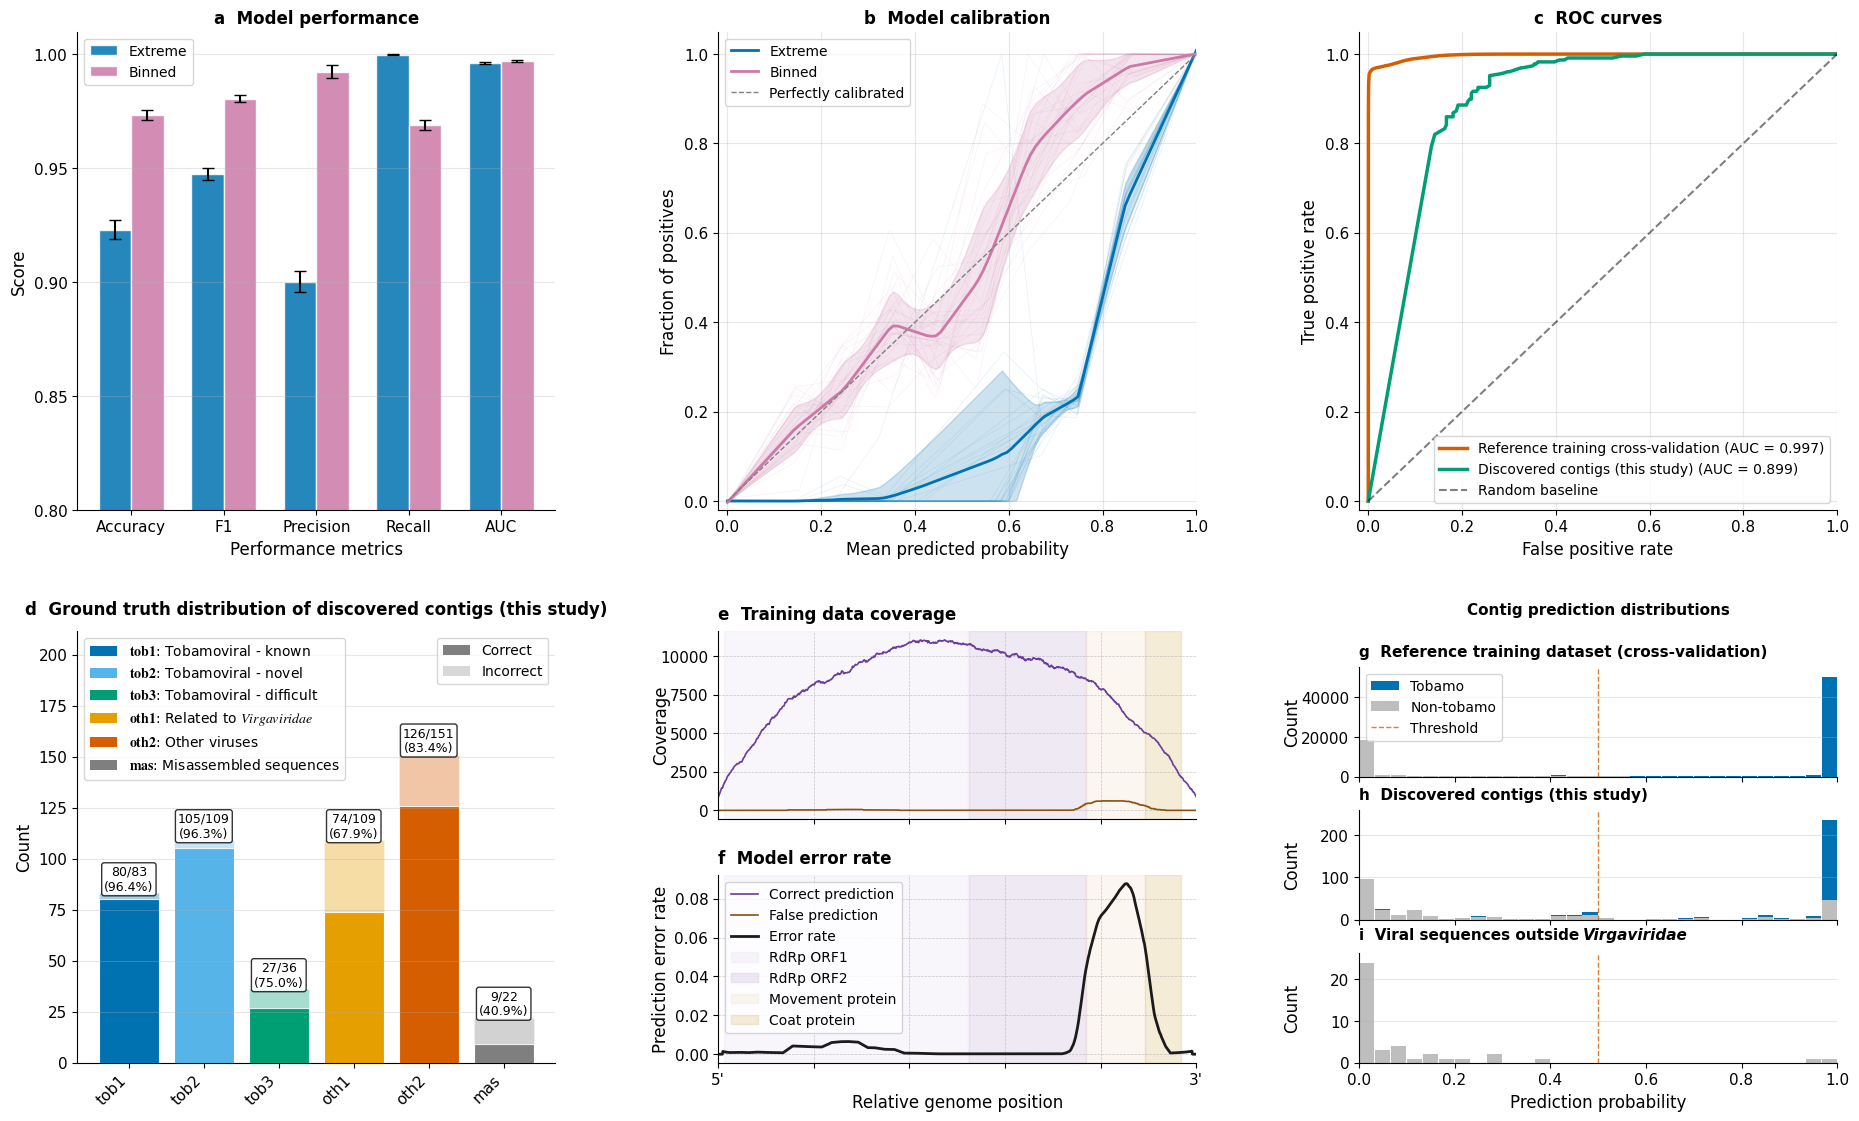

Saved: /home/tobamo/analize/project-tobamo/analysis/model/figures/main_fig.png


In [5]:
# Fix panel i title styling: bold + italic Virgaviridae
# Run this after Cell 4.

if 'ax_f3' not in globals() or 'fig' not in globals():
    raise RuntimeError('Run Cell 4 first to create panel axes.')


def add_mixed_suffix_to_panel_title(ax, prefix, italic_word, fontsize, y, pad, gap_px=4.0):
    fig_local = ax.figure

    temp_prefix = ax.text(
        0,
        0,
        prefix,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=fontsize,
        fontweight='bold',
        alpha=0.0,
    )
    temp_word = ax.text(
        0,
        0,
        italic_word,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=fontsize,
        fontweight='bold',
        fontstyle='italic',
        alpha=0.0,
    )

    fig_local.canvas.draw()
    renderer = fig_local.canvas.get_renderer()
    prefix_width = temp_prefix.get_window_extent(renderer=renderer).width
    axes_bbox = ax.get_window_extent(renderer=renderer)

    temp_prefix.remove()
    temp_word.remove()

    y_ax = y + ((pad * fig_local.dpi / 72.0) / axes_bbox.height)

    ax.text(
        0.0,
        y_ax,
        prefix,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=fontsize,
        fontweight='bold',
        clip_on=False,
    )
    ax.text(
        (prefix_width + gap_px) / axes_bbox.width,
        y_ax,
        italic_word,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=fontsize,
        fontweight='bold',
        fontstyle='italic',
        clip_on=False,
    )


# Remove old panel i title/text and redraw with mixed styling.
ax_f3.set_title('', loc='left')
ax_f3.set_title('', loc='center')
ax_f3.set_title('', loc='right')

for txt in list(ax_f3.texts):
    normalized = ' '.join(txt.get_text().split())
    if normalized in {'Virgaviridae', 'i Viral sequences outside'}:
        txt.remove()

add_mixed_suffix_to_panel_title(
    ax_f3,
    'i  Viral sequences outside',
    'Virgaviridae',
    FS_SUBTITLE,
    PANEL_TITLE_Y,
    padding,
)

fig.canvas.draw()
out_path = figures_dir / 'main_fig.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

try:
    from IPython.display import display
    display(fig)
except Exception:
    pass

print(f'Saved: {out_path}')